In [3]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

warnings.filterwarnings(action='ignore')

# read in configuration file
config_path = '/home/m/m300738/libs/pycompo/config'
config_files = {
    'ngc5004_opv1_w1': f"{config_path}/settings_ngc5004_opv1_w1.yaml",
    'ngc5004_opv4_w1': f"{config_path}/settings_ngc5004_opv4_w1.yaml",
}
config = {i: pcutil.read_yaml_config(c) for i, c in config_files.items()}
ana_times = {i: pcutil.create_analysis_times(c) for i, c in config.items()}

### Read in data

In [ ]:
rb_compo, rb_sigmask, rb_popmeans, rb_compo_corrected = {}, {}, {}, {}

for i, c in config.items():
    # read in composite and adjust units
    inpath = Path(f"{c['data']['outpath']}/{i}/")
    infile_compo = Path(f"{i}_composite_rainbelt.nc")
    rb_compo[i] = xr.open_dataset(str(inpath/infile_compo))

    # read in p-values and calculate field significance
    infile_pvalue = Path(f"{i}_pvalue_rainbelt.nc")
    rb_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
    rb_sigmask[i] = pcsig.get_field_significance(rb_pvalue, alpha_FDR=0.1)

    # correct composites by population means
    rb_popmeans[i] = []
    ipath_popms = Path(f"{c['data']['outpath']}/{i}/popmeans/")

    for start_time, end_time in zip(ana_times[i], ana_times[i][1:]):
        fdate_str = pcutil.create_ftime_str(start_time, end_time)
        ifile = Path(f"{i}_popmeans_rainbelt_{fdate_str}.nc")
        rb_popmeans[i].append(
            xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
            )
    rb_popmeans[i] = xr.concat(rb_popmeans[i], dim='time').mean(dim="time")

    rb_compo_corrected[i] = rb_compo[i] - rb_popmeans[i]
    rb_compo_corrected[i] = pccompo.adjust_units(
        rb_compo_corrected[i], rb_compo_corrected[i].data_vars,
        )
    
    if i != 'ngc5004_opv1_w1':
        rb_compo_corrected[i]['zg'] = rb_compo_corrected['ngc5004_opv1_w1']['zg']

ngc5004_opv4_w1


### Plotting

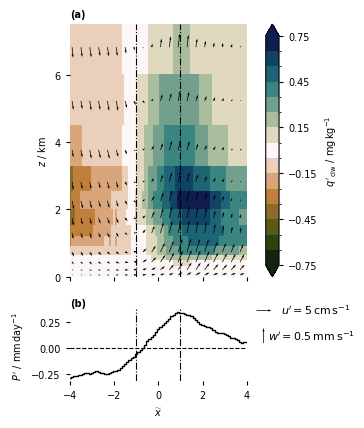

In [ ]:
def save_tight_fixed_width(fig, outpath, width_in=3.2, dpi=600, pad_inches=0.02, **savefig_kwargs):
    # 1) Draw once so text/artists have final extents
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # 2) Measure current tight bounding box (in inches)
    tight_bbox = fig.get_tightbbox(renderer).padded(pad_inches)
    current_tight_width = tight_bbox.width

    # 3) Scale full figure so tight width becomes target width
    scale = width_in / current_tight_width
    w, h = fig.get_size_inches()
    fig.set_size_inches(w * scale, h * scale, forward=True)

    # 4) Redraw and save with tight bbox
    fig.canvas.draw()
    fig.savefig(
        outpath,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=pad_inches,
        **savefig_kwargs
    )



ysel = slice(35, 46)
xsel = slice(1, -2, 4)
zsel = [63, 67, 71, 74, 76, 78, 80, 83, 85, 87, 89]
levels_clw = [-0.8, -0.4, 0.0, 0.4, 0.8]
levels_clw = np.arange(-0.75, 0.8, 0.1)
norm_clw = plt.matplotlib.colors.BoundaryNorm(levels_clw, ncolors=cmocean.cm.tarn.N, clip=True)

plotdata = rb_compo_corrected['ngc5004_opv4_w1']\
    [['clw_ano', 'ua_ano', 'wa_ano', 'pr_ano']].sel(y=ysel).mean(dim='y')
plotdata['zg'] = rb_compo_corrected['ngc5004_opv4_w1']['zg']/1000

vectordata = plotdata.isel(x=xsel).sel(height=zsel)
x_coords = vectordata['En_rota2_featcen_x'].values
y_coords_km = vectordata['zg'].values
U = vectordata['ua_ano'].transpose().values
W = vectordata['wa_ano'].transpose().values * 10

# ------------------------------------------------------------------------------
fig, axs = hffig.init_fig(style=('ams', 'one_column'), asprat=(3.2, 5.5),)
axs.ravel()[0].set_visible(False)  # hide the first (empty) subplot
gs = fig.add_gridspec(
    2, 2, height_ratios=[0.7, 0.2], width_ratios=[0.93, 0.07], hspace=0.20,
    )
main_ax = fig.add_subplot(gs[0, 0])
step_ax = fig.add_subplot(gs[1, 0], sharex=main_ax)
cbar_ax = fig.add_subplot(gs[0, 1])  # colorbar axis (only top row)
hffig.add_subfig_letters(np.array([main_ax, step_ax]))

pl = main_ax.pcolormesh(
    plotdata['En_rota2_featcen_x'], plotdata['zg'],
    plotdata['clw_ano'].transpose(),
    norm=norm_clw, cmap=cmocean.cm.tarn
    )
pl_qv = main_ax.quiver(x_coords, y_coords_km, U, W, zorder=10, color='k')

# Reference vectors for horizontal and vertical velocity anomalies.
qk_u = main_ax.quiverkey(
    pl_qv, X=1.14, Y=-0.13, U=5, label=r"$u\mathrm{'}= 5\,\mathrm{cm\,s}^{-1}$",
    labelpos='E', coordinates='axes', angle=0, color='k',
    fontproperties={'size': 8},
    )
qk_w = main_ax.quiverkey(
    pl_qv, X=1.09, Y=-0.23, U=5, label='',
    coordinates='axes', angle=90, color='k',
    )
main_ax.text(
    1.12, -0.23, r"$w\mathrm{'}= 0.5\,\mathrm{mm\,s}^{-1}$",
    transform=main_ax.transAxes,
    ha='left', va='center', fontsize=8, color='k',
    )

qk_u.set_zorder(20)
qk_w.set_zorder(20)

main_ax.set_xticks([-4, -2, 0, 2, 4])
main_ax.set_yticks([0, 2, 4, 6])
main_ax.set_ylabel('$z$ / km')
main_ax.set_xlim([-4, 4])
main_ax.set_ylim([0, 7.5])
main_ax.axvline(x=-1, color='k', ls='-.', lw=0.8)
main_ax.axvline(x=1, color='k', ls='-.', lw=0.8)
main_ax.tick_params(labelbottom=False)
for spine in main_ax.spines.values(): spine.set_visible(False)

# Step plot of precipitation anomaly.
step_ax.step(plotdata['En_rota2_featcen_x'], plotdata['pr_ano'], where='mid', color='k')
step_ax.set_ylabel("$P\,\mathrm{'}$ / mm$\,$day$^{-1}$")
step_ax.set_xlabel('$\\widetilde{x}$')
step_ax.set_xlim([-4, 4])
step_ax.axvline(x=-1, color='k', ls='-.', lw=0.8)
step_ax.axvline(x=1, color='k', ls='-.', lw=0.8)
step_ax.axhline(y=0, color='k', ls='--', lw=0.8)
for spine in step_ax.spines.values(): spine.set_visible(False)

fig.colorbar(
    pl, cax=cbar_ax, orientation='vertical',
    label="$q\,\mathrm{'}_{\mathrm{clw}}$ / mg$\,$kg$^{-1}$",
    extend='both', ticks=levels_clw[::3],
    )

# Save plot
#plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure05.png')
save_tight_fixed_width(fig, str(outpath / outfile), width_in=3.2, dpi=600)
plt.show()